# Error Analysis on Sample Images
This notebook runs local error analysis using the saved models in `Models/` and the images in the `samples/` directory. 
It helps us visualize how both the Baseline CNN and MobileNetV3 perform on unseen data, specifically highlighting any misclassifications.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Dummy cell - load your test_ds and your best saved models here to get `cnn_probs` and `mob_probs`
# Or carry over variables if running in same session.

def plot_worst_errors(probs, preds, true_labels, paths, class_names, name):
    misclassified_idx = np.where(preds != true_labels)[0]
    if len(misclassified_idx) == 0: return
    
    mis_confidences = [probs[i][preds[i]] for i in misclassified_idx]
    worst_idx = np.argsort(mis_confidences)[::-1][:10]
    
    n_show = min(10, len(worst_idx))
    rows = (n_show + 4) // 5
    fig, axes = plt.subplots(rows, 5, figsize=(20, 4 * rows))
    if rows == 1: axes = [axes]
    
    for ax_i, idx in enumerate(worst_idx[:n_show]):
        sample_idx = misclassified_idx[idx]
        img = Image.open(paths[sample_idx]).convert("RGB")
        row, col = ax_i // 5, ax_i % 5
        axes[row][col].imshow(img)
        axes[row][col].set_title(
            f"True: {class_names[true_labels[sample_idx]]}\n"
            f"Pred: {class_names[preds[sample_idx]]}\n"
            f"Conf: {probs[sample_idx][preds[sample_idx]]:.2f}",
            fontsize=9, color="red"
        )
        axes[row][col].axis("off")
        
    for ax_i in range(n_show, rows * 5):
        axes[ax_i // 5][ax_i % 5].axis("off")
        
    plt.suptitle(f"{name} - Top 10 Worst Errors", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_worst_errors(cnn_probs, cnn_preds, y_true, test_ds.file_paths, CLASS_NAMES, "CNN")
plot_worst_errors(mob_probs, mob_preds, y_true, test_ds.file_paths, CLASS_NAMES, "MobileNetV3")


## Copied from Training Notebook
The following cell and its results were imported from the end of the training phase:

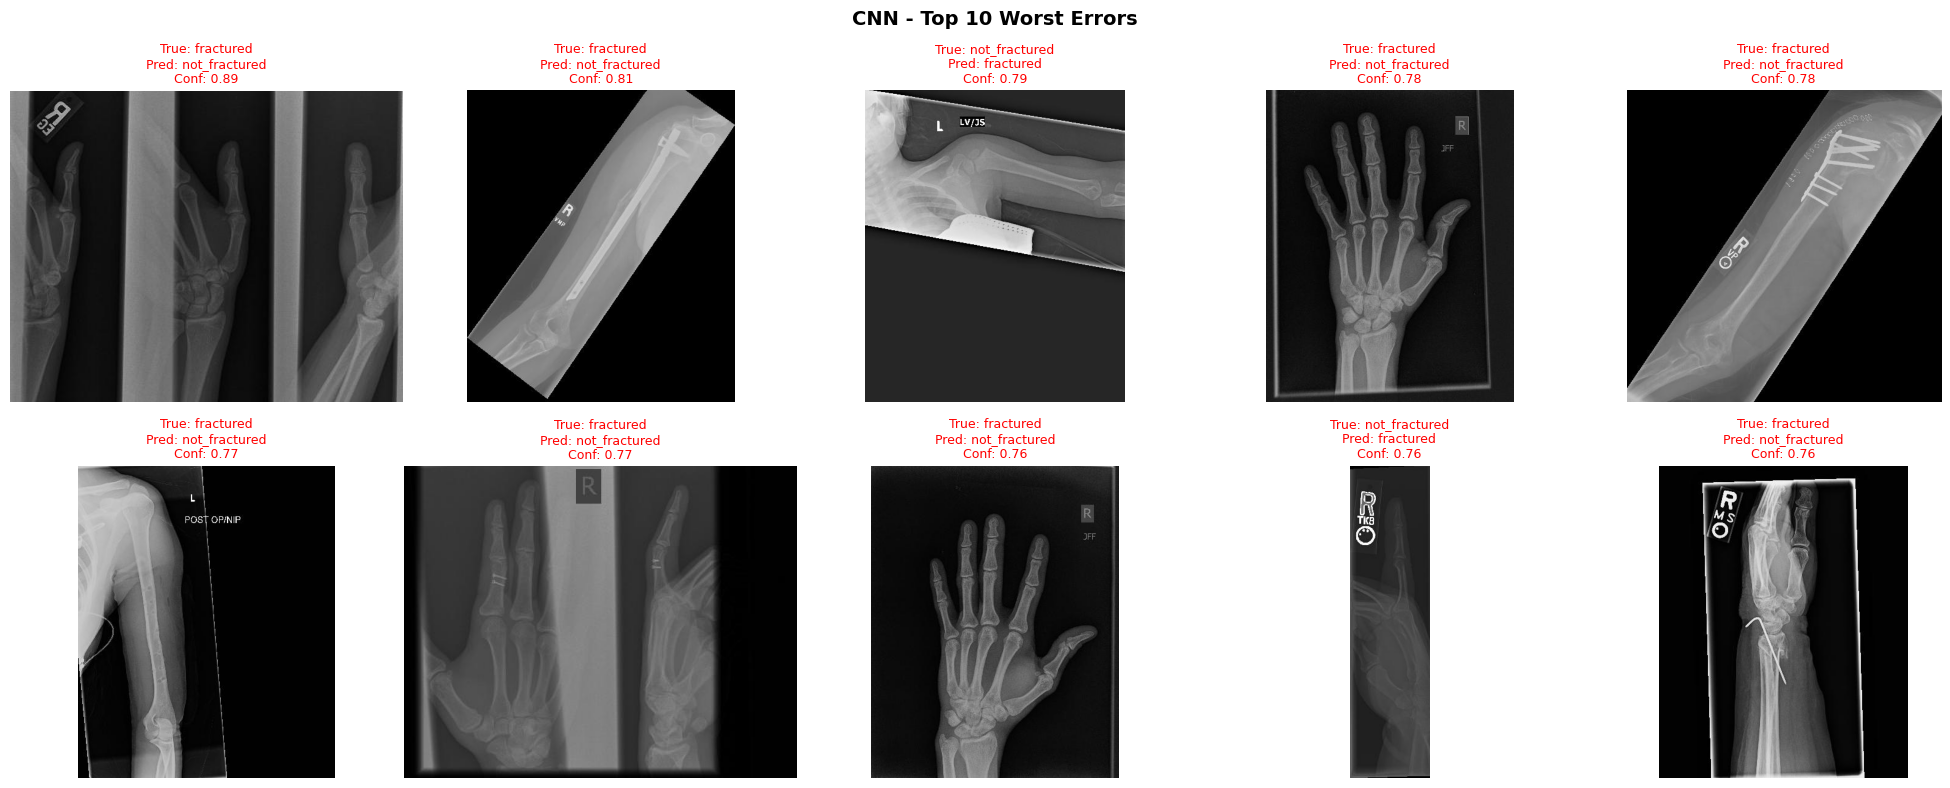

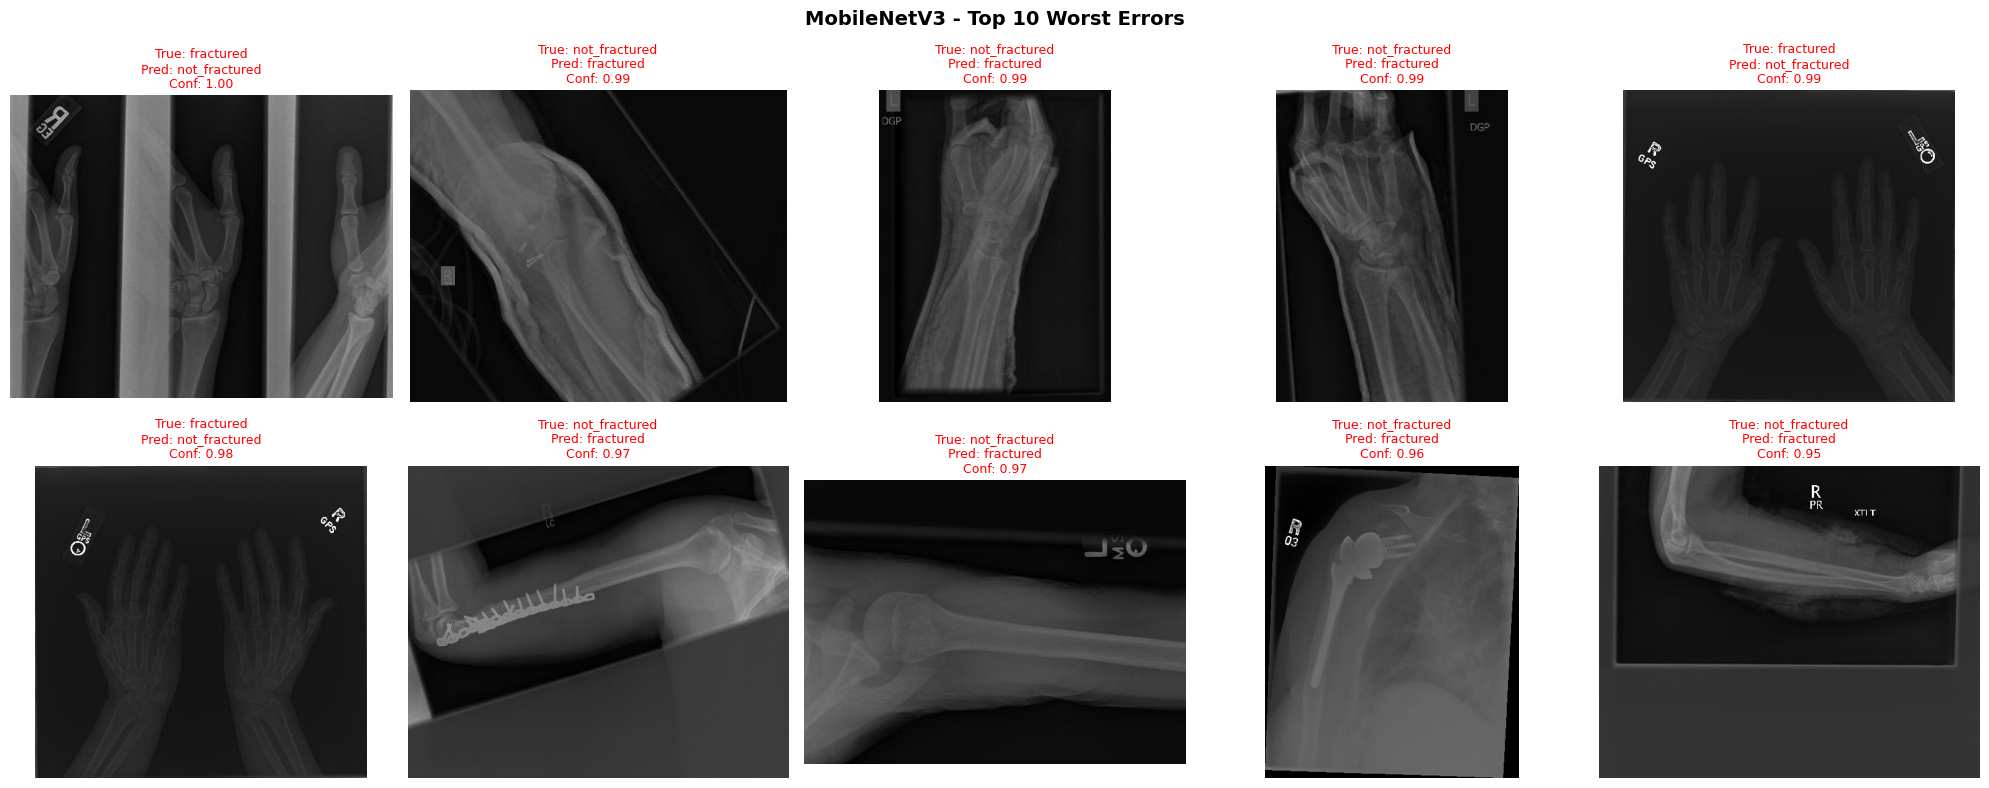

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Dummy cell - load your test_ds and your best saved models here to get `cnn_probs` and `mob_probs`
# Or carry over variables if running in same session.

def plot_worst_errors(probs, preds, true_labels, paths, class_names, name):
    misclassified_idx = np.where(preds != true_labels)[0]
    if len(misclassified_idx) == 0: return
    
    mis_confidences = [probs[i][preds[i]] for i in misclassified_idx]
    worst_idx = np.argsort(mis_confidences)[::-1][:10]
    
    n_show = min(10, len(worst_idx))
    rows = (n_show + 4) // 5
    fig, axes = plt.subplots(rows, 5, figsize=(20, 4 * rows))
    if rows == 1: axes = [axes]
    
    for ax_i, idx in enumerate(worst_idx[:n_show]):
        sample_idx = misclassified_idx[idx]
        img = Image.open(paths[sample_idx]).convert("RGB")
        row, col = ax_i // 5, ax_i % 5
        axes[row][col].imshow(img)
        axes[row][col].set_title(
            f"True: {class_names[true_labels[sample_idx]]}\n"
            f"Pred: {class_names[preds[sample_idx]]}\n"
            f"Conf: {probs[sample_idx][preds[sample_idx]]:.2f}",
            fontsize=9, color="red"
        )
        axes[row][col].axis("off")
        
    for ax_i in range(n_show, rows * 5):
        axes[ax_i // 5][ax_i % 5].axis("off")
        
    plt.suptitle(f"{name} - Top 10 Worst Errors", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_worst_errors(cnn_probs, cnn_preds, y_true, test_ds.file_paths, CLASS_NAMES, "CNN")
plot_worst_errors(mob_probs, mob_preds, y_true, test_ds.file_paths, CLASS_NAMES, "MobileNetV3")


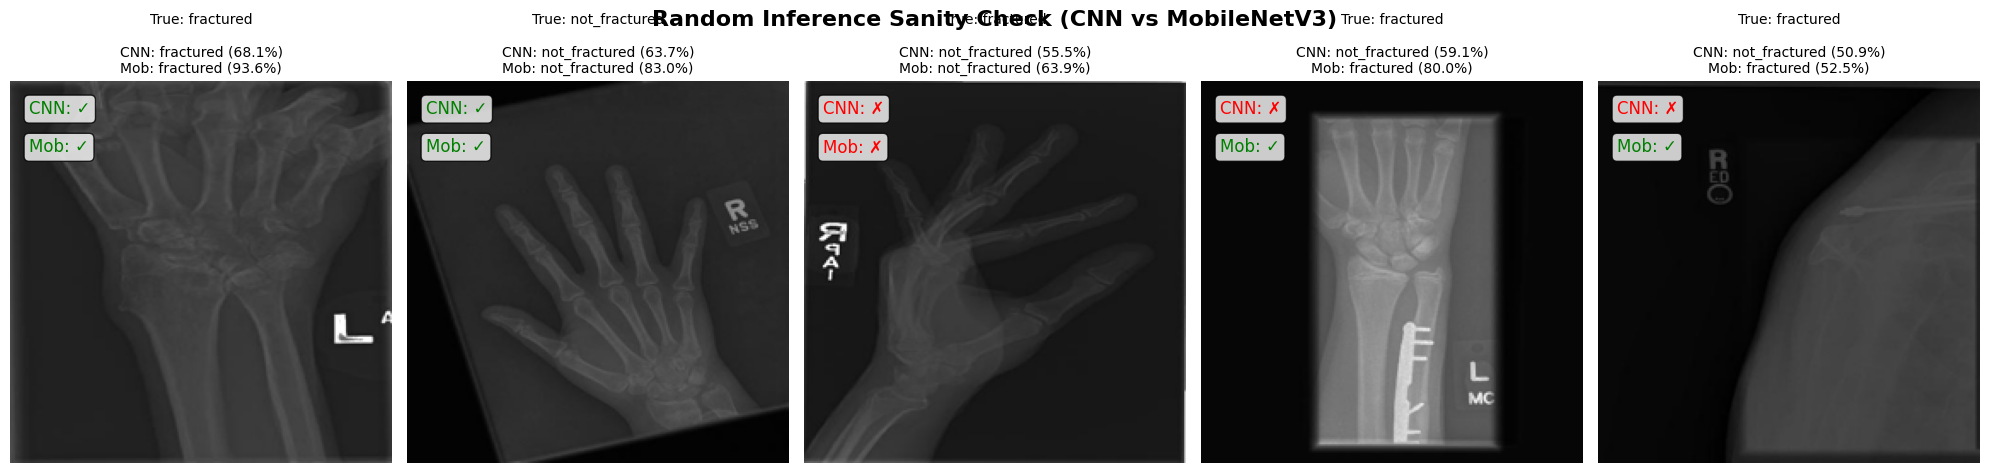

In [23]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

# Grab all image paths from the test directory
all_test_paths = []
for cls in CLASS_NAMES:
    cls_dir = os.path.join(TEST_DIR, cls)
    for fname in os.listdir(cls_dir):
        if fname.endswith(".jpg"):
            all_test_paths.append((os.path.join(cls_dir, fname), cls))

# Select 5 random images
random_samples = random.sample(all_test_paths, 5)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, (img_path, true_label) in enumerate(random_samples):
    # Load raw image for visualization
    raw_img = Image.open(img_path).resize((IMAGE_SIZE, IMAGE_SIZE))
    img_array = keras.utils.img_to_array(raw_img)
    img_batch = np.expand_dims(img_array, axis=0) # Shape: (1, 224, 224, 3)
    
    # 1. Predict with CNN (expects raw 0-255 pixels, handles rescaling internally)
    cnn_prob = model_cnn.predict(img_batch, verbose=0)[0]
    cnn_pred_class = CLASS_NAMES[np.argmax(cnn_prob)]
    cnn_conf = np.max(cnn_prob) * 100
    
    # 2. Predict with MobileNet (expects preprocessed pixels)
    mob_batch = keras.applications.mobilenet_v3.preprocess_input(np.copy(img_batch))
    mob_prob = model_mob.predict(mob_batch, verbose=0)[0]
    mob_pred_class = CLASS_NAMES[np.argmax(mob_prob)]
    mob_conf = np.max(mob_prob) * 100

    # Plotting
    axes[i].imshow(raw_img)
    axes[i].axis('off')
    
    # Color code the titles (Green = Correct, Red = Incorrect)
    cnn_color = "green" if cnn_pred_class == true_label else "red"
    mob_color = "green" if mob_pred_class == true_label else "red"
    
    title_text = f"True: {true_label}\n\n"
    title_text += f"CNN: {cnn_pred_class} ({cnn_conf:.1f}%)\n"
    title_text += f"Mob: {mob_pred_class} ({mob_conf:.1f}%)"
    
    axes[i].set_title(title_text, color='black', fontsize=10)
    
    # Add colored borders or text box to easily spot errors
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    axes[i].text(0.05, 0.95, f"CNN: {'✓' if cnn_pred_class == true_label else '✗'}", 
                 transform=axes[i].transAxes, fontsize=12, color=cnn_color, 
                 verticalalignment='top', bbox=props)
    axes[i].text(0.05, 0.85, f"Mob: {'✓' if mob_pred_class == true_label else '✗'}", 
                 transform=axes[i].transAxes, fontsize=12, color=mob_color, 
                 verticalalignment='top', bbox=props)

plt.suptitle("Random Inference Sanity Check (CNN vs MobileNetV3)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()
